In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


In [3]:
skolky_body = gpd.read_parquet("/Users/annabrazdova/default/kindergartens/geometrie/skolky_body_validated7.parquet")


In [4]:
obce_polygony = gpd.read_file("geometrie/OBCE_SILC.shp").to_crs(5514)
obce_polygony

,KOD_OBEC,NAZ_OBEC,KOD_KRAJ_2,KOD_KRAJ,NAZ_KRAJ,OBLAST_KOD,OBLAST_TEX,TYP_TEXT,Shape_Leng,Shape_Area,TYP_KOD,geometry
0,500011,Želechovice nad Dřevnicí,CZ072,3131,Zlínský kraj,3,řídce obydlená,venkovské obce,24721.171080,1.618763e+07,4,"POLYGON ((-515672.8 -1166154.79, -515289.54 -1..."
1,500020,Petrov nad Desnou,CZ071,3123,Olomoucký kraj,3,řídce obydlená,venkovské obce,15228.386594,1.204318e+07,4,"POLYGON ((-555733.68 -1072434.02, -555222.81 -..."
2,500046,Libhošť,CZ080,3140,Moravskoslezský kraj,3,řídce obydlená,venkovské obce,14023.927023,8.130200e+06,4,"POLYGON ((-488317.45 -1121797.92, -488065.28 -..."
3,500062,Krhová,CZ072,3131,Zlínský kraj,2,středně obydlená,venkovské obce,13364.730297,8.156758e+06,4,"POLYGON ((-491776.64 -1137779.95, -492258.61 -..."
4,500071,Poličná,CZ072,3131,Zlínský kraj,2,středně obydlená,venkovské obce,21905.756085,1.102793e+07,4,"POLYGON ((-497702.34 -1138897.67, -497859.83 -..."
...,...,...,...,...,...,...,...,...,...,...,...,...
6253,599930,Suchdol nad Odrou,CZ080,3140,Moravskoslezský kraj,3,řídce obydlená,venkovské obce,24085.896424,2.292587e+07,4,"POLYGON ((-497583.25 -1116497.55, -497143.18 -..."
6254,599948,Štramberk,CZ080,3140,Moravskoslezský kraj,2,středně obydlená,venkovské obce,16111.755083,9.437697e+06,4,"POLYGON ((-485951.64 -1125945.1, -485876.96 -1..."
6255,599956,Tichá,CZ080,3140,Moravskoslezský kraj,3,řídce obydlená,venkovské obce,19000.327499,1.652153e+07,4,"POLYGON ((-477355.33 -1127934.91, -477309.19 -..."
6256,599964,Tísek,CZ080,3140,Moravskoslezský kraj,3,řídce obydlená,venkovské obce,14127.509258,8.090161e+06,4,"POLYGON ((-490709.98 -1103385.44, -490163.47 -..."


In [5]:
orp_polygony = gpd.read_file("/Users/annabrazdova/default/kindergartens/geometrie/ORP.geojson")
orp_polygony["naz_orp_p"] = orp_polygony["naz_orp_p"].replace({"Praha": "Hlavní město Praha"})

<Axes: >

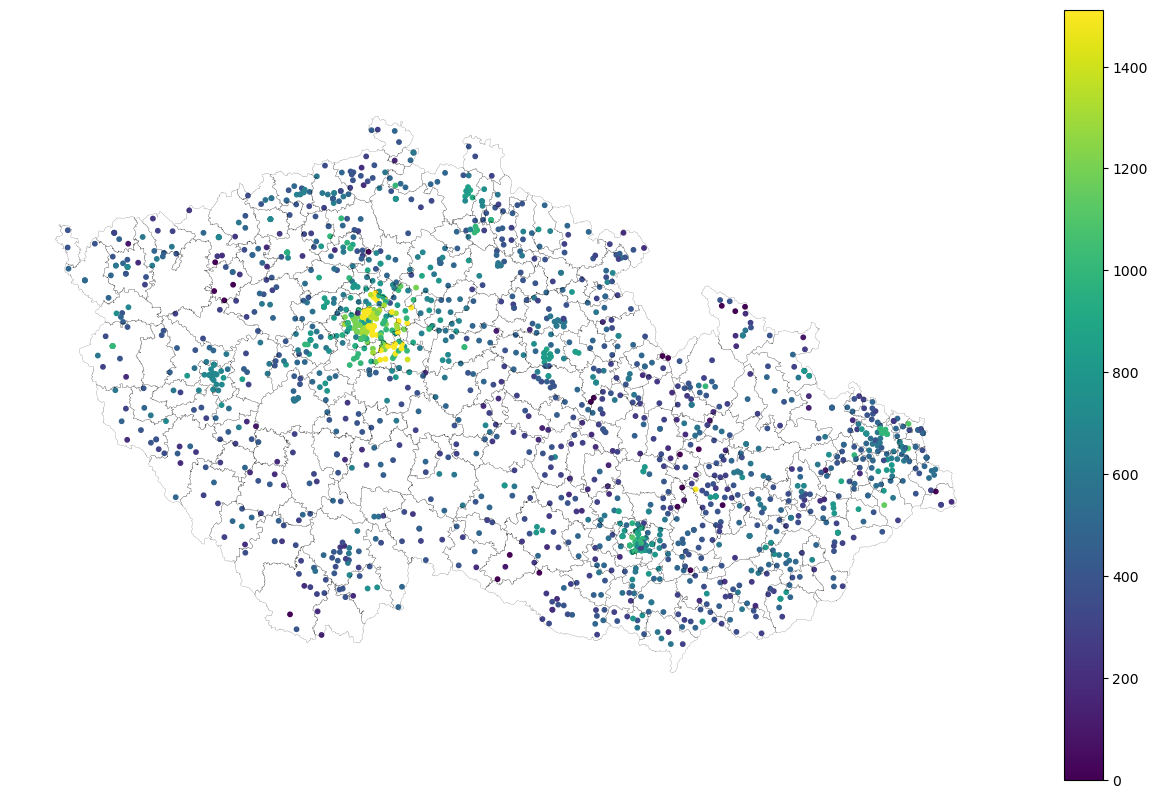

In [6]:
ax = skolky_body.plot("monthly_fe", figsize=(16,10),markersize=10, legend=True)
ax.set_axis_off()
orp_polygony.plot(ax=ax,     facecolor="none",    edgecolor="black", linewidth=0.1)

In [7]:
skolky_body["monthly_fe"].notna().sum()

np.int64(1812)

In [8]:
pocet_skolek = gpd.sjoin(skolky_body, obce_polygony, how="inner", predicate="within")
obce_polygony["count"] = pocet_skolek.groupby("index_right").size()
#obce_polygony["count"] = obce_polygony["count"].fillna(0)



In [15]:
obce_skolky= gpd.sjoin(skolky_body,obce_polygony, how="inner")
#obce_skolky = gpd.sjoin(obce_polygony,skolky_body)

In [16]:
obce_skolky

,Zřizovate,Kraj,Název_ORP,ORP,WWW,Plný_náz,monthly_fe,geometry,index_right,KOD_OBEC,...,KOD_KRAJ_2,KOD_KRAJ,NAZ_KRAJ,OBLAST_KOD,OBLAST_TEX,TYP_TEXT,Shape_Leng,Shape_Area,TYP_KOD,count
RED_IZO,,,,,,,,,,,,,,,,,,,,,
600005399.0,2.0,Hlavní město Praha,Hlavní město Praha,1100.0,http://www.ksidlisti.cz,"Škola Kavčí hory - Mateřská škola, Základní šk...",NaN,POINT (-743268.308 -1047032.287),2515,554782,...,CZ010,3018,Hlavní město Praha,1,hustě obydlená,hl. m. Praha,153019.885850,4.964767e+08,1,300.0
600025713.0,2.0,Kraj Vysočina,Třebíč,6113.0,www.spmstrebic.cz,Speciální mateřská škola Třebíč,NaN,POINT (-650746.181 -1153587.129),5446,590266,...,CZ063,3107,Kraj Vysočina,2,středně obydlená,městské obce,51588.478335,5.758976e+07,3,13.0
600035140.0,2.0,Hlavní město Praha,Hlavní město Praha,1100.0,www.msletenska.cz,Mateřská škola Letenská,1000.0,POINT (-744048.525 -1042979.657),2515,554782,...,CZ010,3018,Hlavní město Praha,1,hustě obydlená,hl. m. Praha,153019.885850,4.964767e+08,1,300.0
600035158.0,2.0,Hlavní město Praha,Hlavní město Praha,1100.0,http://www.msmasna.cz,Mateřská škola Masná,NaN,POINT (-742975.837 -1043007.925),2515,554782,...,CZ010,3018,Hlavní město Praha,1,hustě obydlená,hl. m. Praha,153019.885850,4.964767e+08,1,300.0
600035174.0,2.0,Hlavní město Praha,Hlavní město Praha,1100.0,www.msrevolucni.cz,Mateřská škola Revoluční,1140.0,POINT (-742655.357 -1043955.511),2515,554782,...,CZ010,3018,Hlavní město Praha,1,hustě obydlená,hl. m. Praha,153019.885850,4.964767e+08,1,300.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691017166.0,2.0,Moravskoslezský kraj,Krnov,8114.0,https://www.msliptan.cz/,"Mateřská škola Liptaň, příspěvková organizace",NaN,POINT (-515723.822 -1054507.795),6064,597571,...,CZ080,3140,Moravskoslezský kraj,3,řídce obydlená,venkovské obce,24146.239302,2.045477e+07,4,1.0
691017379.0,2.0,Hlavní město Praha,Hlavní město Praha,1100.0,www.zselektra.cz,"Základní škola a Mateřská škola Elektra, přísp...",1350.0,POINT (-736293.779 -1041437.02),2515,554782,...,CZ010,3018,Hlavní město Praha,1,hustě obydlená,hl. m. Praha,153019.885850,4.964767e+08,1,300.0
691017387.0,2.0,Ústecký kraj,Lovosice,4208.0,https://ms-sedmikraskavrbicany.webnode.cz/,Mateřská škola Sedmikráska Vrbičany - příspěvk...,1000.0,POINT (-760424.597 -998305.23),3361,565903,...,CZ042,3069,Ústecký kraj,3,řídce obydlená,venkovské obce,8943.861946,2.327614e+06,4,1.0


In [17]:
obce_skolky["Kraj"].unique()

array(['Hlavní město Praha', 'Kraj Vysočina', 'Středočeský kraj',
       'Jihočeský kraj', 'Plzeňský kraj', 'Karlovarský kraj',
       'Liberecký kraj', 'Ústecký kraj', 'Královéhradecký kraj',
       'Pardubický kraj', 'Jihomoravský kraj', 'Zlínský kraj',
       'Olomoucký kraj', 'Moravskoslezský kraj'], dtype=object)

In [18]:
avg_price = obce_skolky.groupby('KOD_OBEC').agg({
    'monthly_fe': 'mean',
    **{col: 'first' for col in obce_skolky.columns if col not in ['KOD_OBEC','monthly_fe']}
})


In [19]:
std_price = obce_skolky.groupby('KOD_OBEC').agg({
    'monthly_fe': 'std',
    **{col: 'first' for col in obce_skolky.columns if col not in ['KOD_OBEC','monthly_fe']}
})


In [20]:
obce_skolky.columns

Index(['Zřizovate', 'Kraj', 'Název_ORP', 'ORP', 'WWW', 'Plný_náz',
       'monthly_fe', 'geometry', 'index_right', 'KOD_OBEC', 'NAZ_OBEC',
       'KOD_KRAJ_2', 'KOD_KRAJ', 'NAZ_KRAJ', 'OBLAST_KOD', 'OBLAST_TEX',
       'TYP_TEXT', 'Shape_Leng', 'Shape_Area', 'TYP_KOD', 'count'],
      dtype='object')

# TYP

<Axes: >

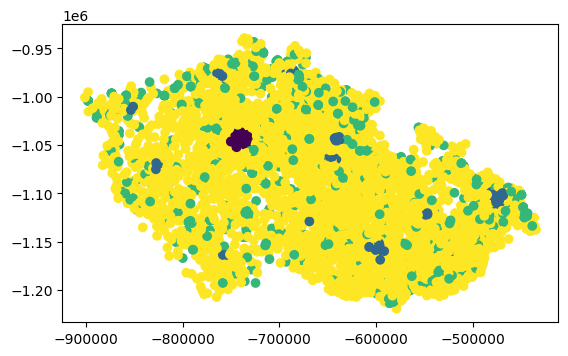

In [21]:
obce_skolky.plot("TYP_KOD")

In [22]:
avg = avg_price.pivot_table(
    values="monthly_fe",
    columns="TYP_KOD",
    aggfunc="mean"
).round()
avg


TYP_KOD,1,2,3,4
monthly_fe,1192.0,671.0,568.0,462.0


In [23]:
avg.mean(axis=0).round()

TYP_KOD
1    1192.0
2     671.0
3     568.0
4     462.0
dtype: float64

In [24]:
std = std_price.pivot_table(
    values="monthly_fe",
    columns="TYP_KOD",
    aggfunc="mean"
).round()
std


TYP_KOD,1,2,3,4
monthly_fe,234.0,79.0,30.0,59.0


In [25]:
std.mean(axis=0).round()

TYP_KOD
1    234.0
2     79.0
3     30.0
4     59.0
dtype: float64

# OBLAST

<Axes: >

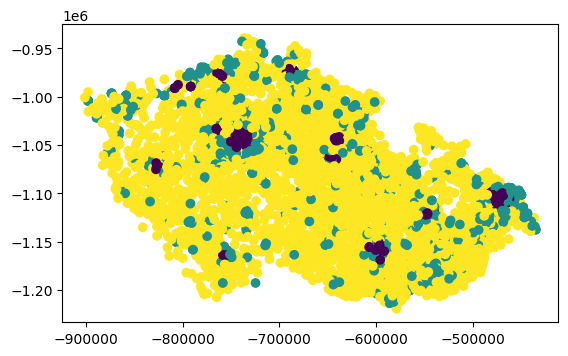

In [26]:
obce_skolky.plot("OBLAST_KOD")

In [27]:
avg = avg_price.pivot_table(
    values="monthly_fe",
    columns="OBLAST_KOD",
    aggfunc="mean"
).round()
avg


OBLAST_KOD,1,2,3
monthly_fe,702.0,651.0,425.0


In [28]:
std = std_price.pivot_table(
    values="monthly_fe",
    columns="OBLAST_KOD",
    aggfunc="mean"
).round()
std


OBLAST_KOD,1,2,3
monthly_fe,91.0,27.0,72.0


# KRAJ

<Axes: >

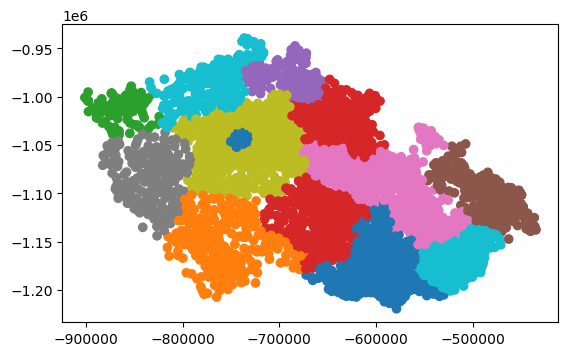

In [29]:
obce_skolky.plot("Kraj")

In [30]:
avg = avg_price.pivot_table(
    values="monthly_fe",
    columns="Kraj",
    aggfunc="mean"
).round()
avg

Kraj,Hlavní město Praha,Jihomoravský kraj,Jihočeský kraj,Karlovarský kraj,Kraj Vysočina,Královéhradecký kraj,Liberecký kraj,Moravskoslezský kraj,Olomoucký kraj,Pardubický kraj,Plzeňský kraj,Středočeský kraj,Zlínský kraj,Ústecký kraj
monthly_fe,1192.0,453.0,382.0,455.0,365.0,442.0,503.0,467.0,380.0,408.0,462.0,706.0,450.0,440.0


In [31]:
std = std_price.pivot_table(
    values="monthly_fe",
    columns="Kraj",
    aggfunc="mean"
).round()
std

Kraj,Hlavní město Praha,Jihomoravský kraj,Jihočeský kraj,Karlovarský kraj,Kraj Vysočina,Královéhradecký kraj,Liberecký kraj,Moravskoslezský kraj,Olomoucký kraj,Pardubický kraj,Plzeňský kraj,Středočeský kraj,Zlínský kraj,Ústecký kraj
monthly_fe,234.0,26.0,7.0,52.0,47.0,64.0,56.0,47.0,49.0,35.0,0.0,17.0,32.0,38.0


# Počty


In [32]:
fee = obce_skolky.loc[obce_skolky["monthly_fe"].notna()]

In [33]:
size_counts_total = obce_skolky.groupby("TYP_KOD").size()
size_counts = fee.groupby('TYP_KOD').size()
table = pd.DataFrame({"total_count": size_counts_total, "count": size_counts})
table['percentage'] = table['count'] / table['total_count'] * 100
table['average_fee'] = obce_skolky.groupby('TYP_KOD')['monthly_fe'].mean()
table['median_fee'] = obce_skolky.groupby('TYP_KOD')['monthly_fe'].median()
table['std_fee'] = obce_skolky.groupby('TYP_KOD')['monthly_fe'].std()
table['Q3'] = obce_skolky.groupby('TYP_KOD')['monthly_fe'].quantile(0.75)

table.round()

,total_count,count,percentage,average_fee,median_fee,std_fee,Q3
TYP_KOD,,,,,,,
1,300,166,55.0,1192.0,1200.0,234.0,1350.0
2,435,185,43.0,748.0,700.0,176.0,900.0
3,981,424,43.0,611.0,600.0,206.0,700.0
4,3072,1037,34.0,462.0,400.0,244.0,500.0


In [34]:
size_counts_total = obce_skolky.groupby("OBLAST_KOD").size()
size_counts = fee.groupby('OBLAST_KOD').size()
table = pd.DataFrame({"total_count": size_counts_total, "count": size_counts})
table['percentage'] = table['count'] / table['total_count'] * 100
table['average_fee'] = obce_skolky.groupby('OBLAST_KOD')['monthly_fe'].mean()
table['median_fee'] = obce_skolky.groupby('OBLAST_KOD')['monthly_fe'].median()
table['std_fee'] = obce_skolky.groupby('OBLAST_KOD')['monthly_fe'].std()
table['Q3'] = obce_skolky.groupby('OBLAST_KOD')['monthly_fe'].quantile(0.75)


table.round()

,total_count,count,percentage,average_fee,median_fee,std_fee,Q3
OBLAST_KOD,,,,,,,
1,760,369,49.0,948.0,900.0,300.0,1200.0
2,1206,489,41.0,650.0,600.0,257.0,800.0
3,2822,954,34.0,427.0,400.0,196.0,500.0


In [35]:
size_counts_total = obce_skolky.groupby("Kraj").size()
size_counts = fee.groupby('Kraj').size()
table = pd.DataFrame({"total_count": size_counts_total, "count": size_counts})
table['percentage'] = table['count'] / table['total_count'] * 100
table['average_fee'] = obce_skolky.groupby('Kraj')['monthly_fe'].mean()
table['median_fee'] = obce_skolky.groupby('Kraj')['monthly_fe'].median()
table['std_fee'] = obce_skolky.groupby('Kraj')['monthly_fe'].std()
table['Q3'] = obce_skolky.groupby('Kraj')['monthly_fe'].quantile(0.75)


table.round()

,total_count,count,percentage,average_fee,median_fee,std_fee,Q3
Kraj,,,,,,,
Hlavní město Praha,299,166,56.0,1192.0,1200.0,234.0,1350.0
Jihomoravský kraj,628,220,35.0,575.0,500.0,242.0,800.0
Jihočeský kraj,300,104,35.0,386.0,400.0,130.0,450.0
Karlovarský kraj,117,45,38.0,479.0,500.0,146.0,600.0
Kraj Vysočina,281,85,30.0,379.0,350.0,171.0,500.0
Královéhradecký kraj,289,98,34.0,469.0,475.0,136.0,600.0
Liberecký kraj,213,71,33.0,612.0,600.0,228.0,790.0
Moravskoslezský kraj,406,183,45.0,539.0,500.0,216.0,600.0
Olomoucký kraj,349,134,38.0,421.0,400.0,215.0,588.0


# Kombinace

In [36]:
obce_skolky["kraj_oblast_typ"] = obce_skolky["Kraj"].astype("str") + obce_skolky["OBLAST_KOD"].astype("str") + obce_skolky["TYP_KOD"].astype("str")

In [37]:
fee = obce_skolky.loc[obce_skolky["monthly_fe"].notna()]

In [38]:
obce_skolky["kraj_oblast_typ"].unique()

array(['Hlavní město Praha11', 'Kraj Vysočina23', 'Středočeský kraj23',
       'Středočeský kraj34', 'Středočeský kraj33', 'Středočeský kraj24',
       'Středočeský kraj13', 'Středočeský kraj11', 'Jihočeský kraj12',
       'Jihočeský kraj34', 'Jihočeský kraj24', 'Jihočeský kraj33',
       'Jihočeský kraj23', 'Kraj Vysočina34', 'Kraj Vysočina33',
       'Plzeňský kraj33', 'Plzeňský kraj34', 'Plzeňský kraj23',
       'Karlovarský kraj23', 'Karlovarský kraj34', 'Karlovarský kraj24',
       'Karlovarský kraj33', 'Plzeňský kraj12', 'Plzeňský kraj24',
       'Liberecký kraj33', 'Liberecký kraj34', 'Liberecký kraj23',
       'Liberecký kraj24', 'Ústecký kraj23', 'Ústecký kraj34',
       'Ústecký kraj33', 'Ústecký kraj24', 'Ústecký kraj13',
       'Liberecký kraj12', 'Ústecký kraj12', 'Královéhradecký kraj34',
       'Královéhradecký kraj12', 'Královéhradecký kraj23',
       'Královéhradecký kraj24', 'Pardubický kraj34', 'Pardubický kraj23',
       'Pardubický kraj33', 'Pardubický kraj24', 'Kr

In [39]:
size_counts_total = obce_skolky.groupby("kraj_oblast_typ").size()
size_counts = fee.groupby('kraj_oblast_typ').size()
table = pd.DataFrame({"total_count": size_counts_total, "count": size_counts})
table['percentage'] = table['count'] / table['total_count'] * 100
table['average_fee'] = obce_skolky.groupby('kraj_oblast_typ')['monthly_fe'].mean()
table['median_fee'] = obce_skolky.groupby('kraj_oblast_typ')['monthly_fe'].median()
table['std_fee'] = obce_skolky.groupby('kraj_oblast_typ')['monthly_fe'].std()
table['Q4'] = obce_skolky.groupby('kraj_oblast_typ')['monthly_fe'].quantile(0.75)


table

,total_count,count,percentage,average_fee,median_fee,std_fee,Q4
kraj_oblast_typ,,,,,,,
Hlavní město Praha11,299,166.0,55.518395,1191.765060,1200.0,233.597061,1350.0
Jihomoravský kraj12,138,64.0,46.376812,848.671875,900.0,156.098875,1000.0
Jihomoravský kraj23,63,22.0,34.920635,634.090909,600.0,163.580739,787.5
Jihomoravský kraj24,60,18.0,30.000000,544.444444,600.0,151.355531,637.5
Jihomoravský kraj33,12,7.0,58.333333,621.428571,600.0,184.519969,800.0
...,...,...,...,...,...,...,...
Ústecký kraj13,8,6.0,75.000000,633.333333,700.0,121.106014,700.0
Ústecký kraj23,93,40.0,43.010753,625.750000,585.0,197.962539,700.0
Ústecký kraj24,35,7.0,20.000000,550.000000,500.0,210.158670,550.0


In [40]:
table

,total_count,count,percentage,average_fee,median_fee,std_fee,Q4
kraj_oblast_typ,,,,,,,
Hlavní město Praha11,299,166.0,55.518395,1191.765060,1200.0,233.597061,1350.0
Jihomoravský kraj12,138,64.0,46.376812,848.671875,900.0,156.098875,1000.0
Jihomoravský kraj23,63,22.0,34.920635,634.090909,600.0,163.580739,787.5
Jihomoravský kraj24,60,18.0,30.000000,544.444444,600.0,151.355531,637.5
Jihomoravský kraj33,12,7.0,58.333333,621.428571,600.0,184.519969,800.0
...,...,...,...,...,...,...,...
Ústecký kraj13,8,6.0,75.000000,633.333333,700.0,121.106014,700.0
Ústecký kraj23,93,40.0,43.010753,625.750000,585.0,197.962539,700.0
Ústecký kraj24,35,7.0,20.000000,550.000000,500.0,210.158670,550.0


In [41]:
obce = obce_skolky.merge(table, left_on ="kraj_oblast_typ", how="outer", right_index=True)

In [42]:
k = obce_polygony.merge(
    obce.drop(columns="geometry"),
    on="KOD_OBEC",
    how="outer"
)
k= k.drop_duplicates("geometry")

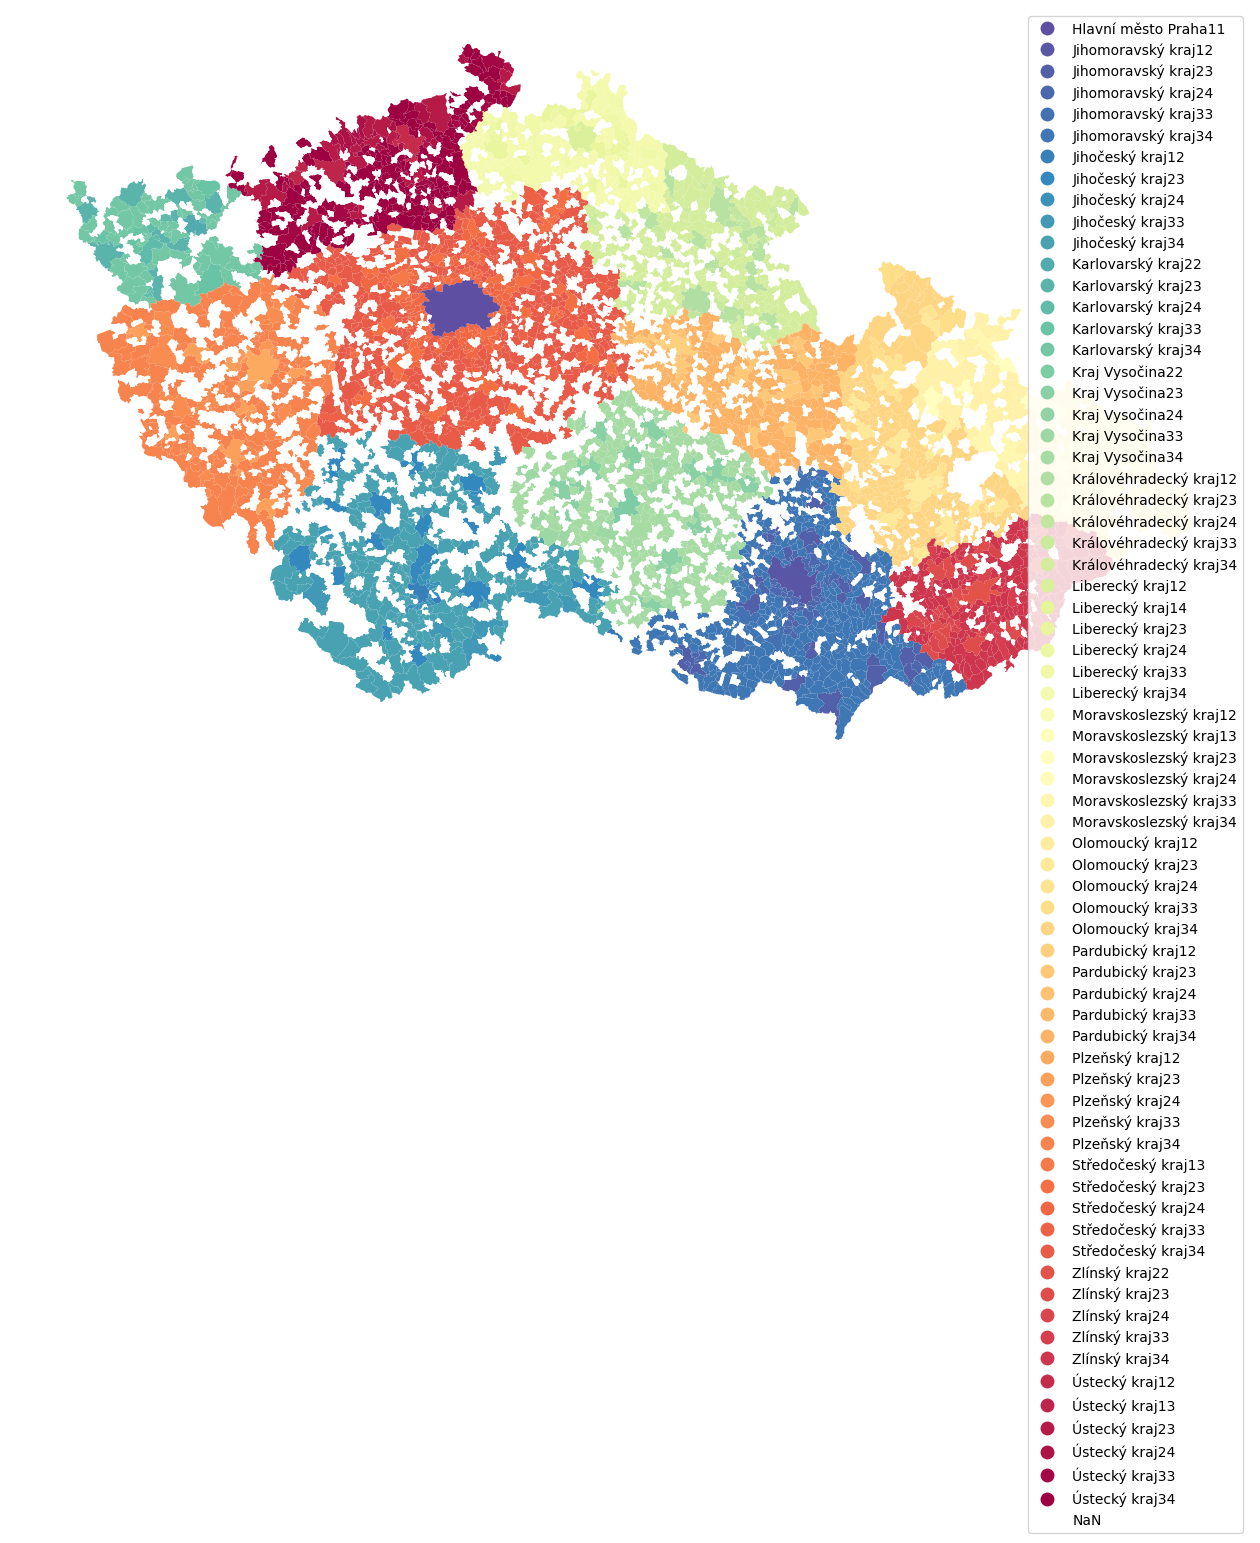

In [43]:
k.plot("kraj_oblast_typ", figsize=(16,10),legend=True,cmap="Spectral_r",missing_kwds={"color": "white"},
).set_axis_off()

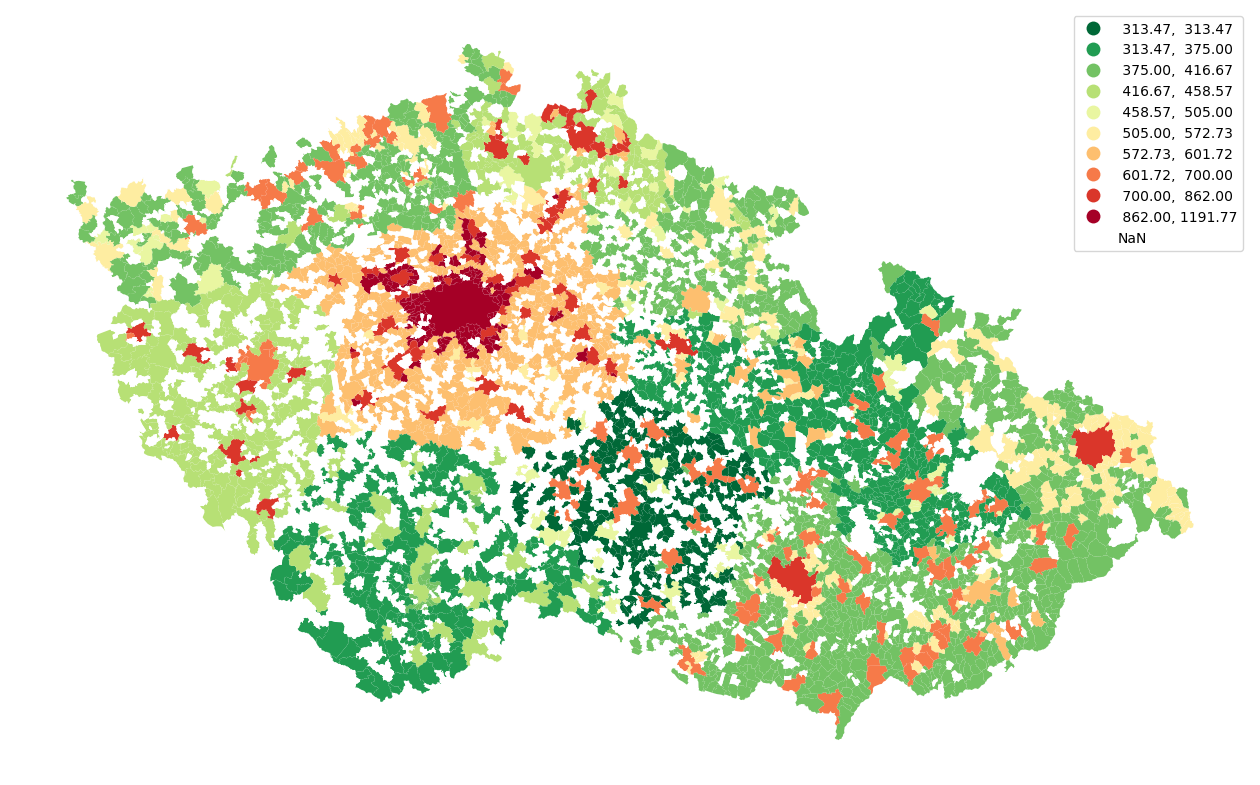

In [44]:
k.plot(
    column="average_fee",
    figsize=(16,10),
    legend=True,
    cmap="RdYlGn_r",
    missing_kwds={"color": "white"},
    scheme="natural_breaks",
    k=10
).set_axis_off()

In [41]:
kraje_polygony = gpd.read_file("/Users/annabrazdova/default/kindergartens/geometrie/kraje.geojson")
kraje_polygony = kraje_polygony.to_crs(5514)

In [42]:
kraje_polygony

,OBJECTID_1,OBJECTID,NAZEV,NUTS2,NUTS3,NUTS3_1,nazev_kraj,o_po_m,o_po_z,o_po,...,o_bydl_1_m,o_bydl_1_z,o_bydl_1,b_domy_p,b_byt_p,b_domy_trv,b_byt_trv,b_obyt_pl,Shape_Leng,geometry
0,1,1,Hlavní město Praha,CZ01,CZ010,CZ010,Hlavní město Praha,613738,655058,1268796,...,409441,450768,860209,99949,587832,92927,542168,26802918,1.604649e+05,"POLYGON ((-733676.915 -1034193.13, -733607.439..."
1,2,2,Středočeský kraj,CZ02,CZ020,CZ020,Středočeský kraj,637252,651959,1289211,...,459534,477827,937361,353037,582294,286780,482860,30793300,3.351320e+06,"POLYGON ((-769729.172 -1014516.35, -769718.545..."
2,3,3,Jihočeský kraj,CZ03,CZ031,CZ031,Jihočeský kraj,308296,320040,628336,...,229280,239532,468812,163889,308712,123048,247608,15069274,2.323215e+06,"POLYGON ((-675456.843 -1159538.927, -675495.81..."
3,4,4,Plzeňský kraj,CZ03,CZ032,CZ032,Plzeňský kraj,282137,288264,570401,...,204162,211959,416121,131052,268963,105835,226298,13359114,1.777608e+06,"POLYGON ((-820266.624 -1030147.187, -820272.78..."
4,5,5,Karlovarský kraj,CZ04,CZ041,CZ041,Karlovarský kraj,145483,150112,295595,...,96493,101536,198029,44979,135091,39845,119403,6289506,8.728456e+05,"POLYGON ((-849532.985 -985353.283, -849509.635..."
5,6,6,Ústecký kraj,CZ04,CZ042,CZ042,Ústecký kraj,397453,411508,808961,...,271676,286960,558636,135999,377133,115679,330981,17756897,1.490204e+06,"MULTIPOLYGON (((-769729.172 -1014516.35, -7696..."
6,7,7,Liberecký kraj,CZ05,CZ051,CZ051,Liberecký kraj,211537,220902,432439,...,150666,159103,309769,92345,205187,73380,171328,9752557,8.180257e+05,"POLYGON ((-686894.263 -945560.824, -686872.591..."
7,8,8,Královéhradecký kraj,CZ05,CZ052,CZ052,Královéhradecký kraj,268967,278949,547916,...,198475,206462,404937,137051,259995,109736,215277,12714740,1.201731e+06,"POLYGON ((-652460.832 -977476.209, -652410.094..."
8,9,9,Pardubický kraj,CZ05,CZ053,CZ053,Pardubický kraj,252310,259317,511627,...,188336,195443,383779,128618,233798,104850,196288,11825522,1.079417e+06,"MULTIPOLYGON (((-632281.464 -1099040.098, -632..."
9,10,10,Kraj Vysočina,CZ06,CZ063,CZ063,Kraj Vysočina,250196,255369,505565,...,194692,199426,394118,136766,230025,108062,188191,11910883,1.448298e+06,"MULTIPOLYGON (((-675456.843 -1159538.927, -675..."


In [108]:
orp_polygony = gpd.read_file("/Users/annabrazdova/default/kindergartens/geometrie/ORP.geojson")
orp_polygony["naz_orp_p"] = orp_polygony["naz_orp_p"].replace({"Praha": "Hlavní město Praha"})

In [ ]:
str